In [1]:
from models.utils.data import load_groundtruths

/Users/albertomarengo/Bitstrapped-Project/my_yolo/yol-venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_path = "dataset/Dataset/validation/Vehicle registration plate"

In [3]:
data = load_groundtruths(data_path, train=False, shuffle=False, debug=True)

Total 386 images and 386 boxes loaded from: dataset/Dataset/validation/Vehicle registration plate
Debug mode enabled: Only using 10 samples for set: validation


In [4]:
images, boxes, labels, tot_snamples = data
idx = 1
sample = (images[idx], boxes[idx], labels[idx])

In [5]:
sample

('dataset/Dataset/validation/Vehicle registration plate/00723dac8201a83e.jpg',
 [[1.398784, 408.147456, 60.326912, 438.24460799999997],
  [787.3146879999999, 347.72966399999996, 830.90432, 374.35161600000004]],
 [1, 1])

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

from models.utils import visualization as utils

def plot_predictions(sample):
    # Define subplots
    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(10, 10),
    )
    image = cv2.imread(sample[0])
    # Plot Predictions.
    orig_image = utils.draw_bbox(
        image,
        np.array(sample[1], dtype=np.int32),
        labels=sample[2],
        color=(255, 0, 0),
        thickness=2,
    )


    ax.imshow(orig_image)
    ax.axis("off")

    plt.figtext(0.50, 0.9, "Predictions", fontsize=20, color="r", ha="center")

    plt.show(block=False)

    return fig

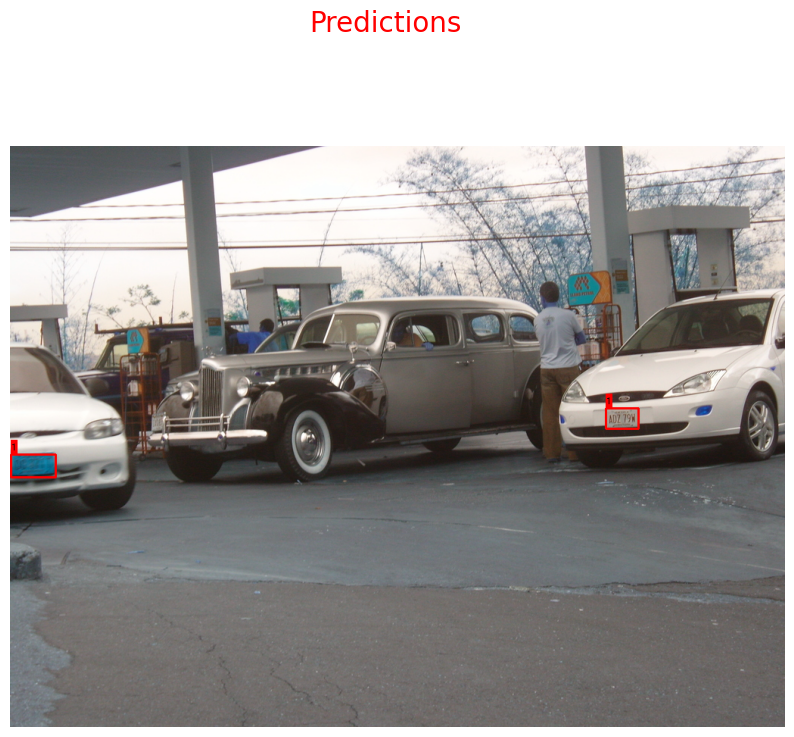

In [7]:
fig = plot_predictions(sample)

In [8]:
image = cv2.imread(sample[0])
img_size = image.shape
img_size

(768, 1024, 3)

In [9]:
bboxes = sample[1]
bboxes

[[1.398784, 408.147456, 60.326912, 438.24460799999997],
 [787.3146879999999, 347.72966399999996, 830.90432, 374.35161600000004]]

In [10]:
import torch
import math

input_size = (300, 300)
fm_size = 4

img_h, img_w = input_size

grid_h = math.ceil(img_h / fm_size)
grid_w = math.ceil(img_w / fm_size)

grid_h_coords = torch.arange(0, fm_size, dtype=torch.float) * grid_h + grid_h / 2
grid_w_coords = torch.arange(0, fm_size, dtype=torch.float) * grid_w + grid_w / 2

In [11]:
grid_h

75

In [12]:
torch.arange(0, fm_size, dtype=torch.float)

tensor([0., 1., 2., 3.])

In [13]:
grid_h_coords

tensor([ 37.5000, 112.5000, 187.5000, 262.5000])

In [14]:
grid_w_coords

tensor([ 37.5000, 112.5000, 187.5000, 262.5000])

In [15]:
x, y = torch.meshgrid(grid_w_coords, grid_h_coords, indexing="xy")

xyxy = torch.stack([x, y, x, y], dim=2)

In [16]:
x

tensor([[ 37.5000, 112.5000, 187.5000, 262.5000],
        [ 37.5000, 112.5000, 187.5000, 262.5000],
        [ 37.5000, 112.5000, 187.5000, 262.5000],
        [ 37.5000, 112.5000, 187.5000, 262.5000]])

In [17]:
y

tensor([[ 37.5000,  37.5000,  37.5000,  37.5000],
        [112.5000, 112.5000, 112.5000, 112.5000],
        [187.5000, 187.5000, 187.5000, 187.5000],
        [262.5000, 262.5000, 262.5000, 262.5000]])

In [18]:
xyxy.shape

torch.Size([4, 4, 4])

In [19]:
boxes = (xyxy).reshape(-1, 4)

In [20]:
boxes.shape

torch.Size([16, 4])

In [21]:
def generate_anchors(anchor_area, aspect_ratios, scales):
    anchors = []

    for scale in scales:
        for ratio in aspect_ratios:
            h = scale * (math.sqrt(anchor_area / ratio))  # h*w * h/w = sqrt(h**2)
            w = ratio * h  # w/h * h

            # Assume the anchor box is centered at origin (0, 0)
            # Get xmin, ymin, xmax, ymax of anchor box w.r.t origin (0, 0)
            box_w_half = w / 2
            box_h_half = h / 2

            x1 = 0.0 - box_w_half
            y1 = 0.0 - box_h_half

            x2 = 0.0 + box_w_half
            y2 = 0.0 + box_h_half

            anchors.append([x1, y1, x2, y2])

    return torch.tensor(anchors, dtype=torch.float)

In [22]:
anchors = generate_anchors(anchor_area=16 * 16, aspect_ratios=[0.5, 1.0, 2.0], scales=[1.0, 2.0])

In [23]:
anchors.shape

torch.Size([6, 4])

In [24]:
anchors = anchors.reshape(-1, 1, 1, 4)
boxes = (xyxy + anchors).permute(1, 2, 0, 3).reshape(-1, 4)

In [25]:
boxes.shape

torch.Size([96, 4])

In [26]:
(xyxy + anchors).shape

torch.Size([6, 4, 4, 4])

In [27]:
boxes

tensor([[ 31.8431,  26.1863,  43.1569,  48.8137],
        [ 29.5000,  29.5000,  45.5000,  45.5000],
        [ 26.1863,  31.8431,  48.8137,  43.1569],
        [ 26.1863,  14.8726,  48.8137,  60.1274],
        [ 21.5000,  21.5000,  53.5000,  53.5000],
        [ 14.8726,  26.1863,  60.1274,  48.8137],
        [106.8431,  26.1863, 118.1569,  48.8137],
        [104.5000,  29.5000, 120.5000,  45.5000],
        [101.1863,  31.8431, 123.8137,  43.1569],
        [101.1863,  14.8726, 123.8137,  60.1274],
        [ 96.5000,  21.5000, 128.5000,  53.5000],
        [ 89.8726,  26.1863, 135.1274,  48.8137],
        [181.8431,  26.1863, 193.1569,  48.8137],
        [179.5000,  29.5000, 195.5000,  45.5000],
        [176.1863,  31.8431, 198.8137,  43.1569],
        [176.1863,  14.8726, 198.8137,  60.1274],
        [171.5000,  21.5000, 203.5000,  53.5000],
        [164.8726,  26.1863, 210.1274,  48.8137],
        [256.8431,  26.1863, 268.1569,  48.8137],
        [254.5000,  29.5000, 270.5000,  45.5000],


In [28]:
def encode_boxes(boxes, anchors):
    a_wh = anchors[:, 2:] - anchors[:, :2]
    a_ctr = anchors[:, :2] + 0.5 * a_wh
    b_wh = boxes[:, 2:] - boxes[:, :2]
    b_ctr = boxes[:, :2] + 0.5 * b_wh

    dxdy = (b_ctr - a_ctr) / a_wh
    dwdh = torch.log((b_wh / a_wh).clamp(min=1e-6))
    return torch.cat([dxdy, dwdh], dim=1)

In [29]:
bboxes_norm = torch.tensor(bboxes, dtype=torch.float)

bboxes_norm[:, [0, 2]] *= (input_size[1] / img_size[1])
bboxes_norm[:, [1, 3]] *= (input_size[0] / img_size[0])

In [30]:
bboxes_norm

tensor([[  0.4098, 159.4326,  17.6739, 171.1893],
        [230.6586, 135.8319, 243.4290, 146.2311]])

In [31]:
# encode_boxes(bboxes_norm, boxes)

In [32]:
from models.src.encoder import DataEncoder

encoder = DataEncoder(input_size[:2])

In [33]:
box_enc, lab_enc = encoder.encode(bboxes_norm, torch.tensor(sample[2], dtype=torch.int64))

In [34]:
box_enc.shape

torch.Size([121024, 4])

In [35]:
lab_enc.shape

torch.Size([121024])

In [36]:
box_enc

tensor([[ 3.9365e+00,  4.5647e+02, -1.7766e-01,  5.9485e+00],
        [ 5.0820e+00,  3.5358e+02,  1.0994e+00,  4.6714e+00],
        [ 6.2242e+00,  2.8870e+02,  2.1131e+00,  3.6578e+00],
        ...,
        [-9.6065e-01, -1.0129e+00, -2.4894e+01, -2.1322e+01],
        [-1.1766e+00, -8.2704e-01, -2.3880e+01, -2.2335e+01],
        [-1.6639e+00, -5.8481e-01, -2.2147e+01, -2.4068e+01]])

In [37]:
import torch.nn.functional as F
num_classes = 2  # background + object

labels = lab_enc.clone().long()
labels[labels < 0] = 0   # turn -1 into background before one-hot

fake_logits = F.one_hot(labels, num_classes=num_classes).float()
fake_logits[lab_enc < 0] = 0.0

In [38]:
encoder.decode(box_enc, fake_logits, 'cpu')

tensor([[230.6586, 135.8319, 243.4290, 146.2311,   0.7311,   1.0000],
        [  0.4098, 159.4326,  17.6739, 171.1893,   0.7311,   1.0000]])

In [39]:
xyxy.reshape(-1, 2)

tensor([[ 37.5000,  37.5000],
        [ 37.5000,  37.5000],
        [112.5000,  37.5000],
        [112.5000,  37.5000],
        [187.5000,  37.5000],
        [187.5000,  37.5000],
        [262.5000,  37.5000],
        [262.5000,  37.5000],
        [ 37.5000, 112.5000],
        [ 37.5000, 112.5000],
        [112.5000, 112.5000],
        [112.5000, 112.5000],
        [187.5000, 112.5000],
        [187.5000, 112.5000],
        [262.5000, 112.5000],
        [262.5000, 112.5000],
        [ 37.5000, 187.5000],
        [ 37.5000, 187.5000],
        [112.5000, 187.5000],
        [112.5000, 187.5000],
        [187.5000, 187.5000],
        [187.5000, 187.5000],
        [262.5000, 187.5000],
        [262.5000, 187.5000],
        [ 37.5000, 262.5000],
        [ 37.5000, 262.5000],
        [112.5000, 262.5000],
        [112.5000, 262.5000],
        [187.5000, 262.5000],
        [187.5000, 262.5000],
        [262.5000, 262.5000],
        [262.5000, 262.5000]])

In [40]:
xy = torch.stack([x, y], dim=2)

In [41]:
xy.shape

torch.Size([4, 4, 2])

In [42]:
cell_centers = xy.reshape(-1, 2)

In [43]:
cell_centers

tensor([[ 37.5000,  37.5000],
        [112.5000,  37.5000],
        [187.5000,  37.5000],
        [262.5000,  37.5000],
        [ 37.5000, 112.5000],
        [112.5000, 112.5000],
        [187.5000, 112.5000],
        [262.5000, 112.5000],
        [ 37.5000, 187.5000],
        [112.5000, 187.5000],
        [187.5000, 187.5000],
        [262.5000, 187.5000],
        [ 37.5000, 262.5000],
        [112.5000, 262.5000],
        [187.5000, 262.5000],
        [262.5000, 262.5000]])

In [44]:
bboxes_norm

tensor([[  0.4098, 159.4326,  17.6739, 171.1893],
        [230.6586, 135.8319, 243.4290, 146.2311]])

In [45]:
def get_center_differences(boxes, cell_centers):
    box_centers = torch.stack(
    [
        (boxes[:, 0] + boxes[:, 2]) / 2,  # box center x
        (boxes[:, 1] + boxes[:, 3]) / 2,  # box center y
    ],
    dim=1
)  # shape: [n_boxes, 2]

    # broadcast to [16, n_boxes, 2]
    diff = cell_centers[:, None, :] - box_centers[None, :, :]

    return diff

In [46]:
diff = get_center_differences(bboxes_norm, cell_centers)

In [47]:
inside = (diff.abs() <= 37.5).all(dim=2)

In [48]:
inside

tensor([[False, False],
        [False, False],
        [False, False],
        [False, False],
        [False, False],
        [False, False],
        [False, False],
        [False,  True],
        [ True, False],
        [False, False],
        [False, False],
        [False, False],
        [False, False],
        [False, False],
        [False, False],
        [False, False]])

In [49]:
inside.any(dim=1)

tensor([False, False, False, False, False, False, False,  True,  True, False,
        False, False, False, False, False, False])

In [50]:
inside.float().argmax(dim=1)

tensor([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [68]:
def assign_boxes_to_cells(cell_centers, boxes, classes, cell_size, background_id=0):
    box_centers = torch.stack(
        [
            (boxes[:, 0] + boxes[:, 2]) / 2,
            (boxes[:, 1] + boxes[:, 3]) / 2,
        ],
        dim=1
    )

    diff = cell_centers[:, None, :] - box_centers[None, :, :]
    half = cell_size / 2
    inside = (diff.abs() <= half).all(dim=2)

    assigned_box_ids = torch.full((cell_centers.shape[0],), -1, dtype=torch.long)
    assigned_classes = torch.full((cell_centers.shape[0],), background_id, dtype=torch.long)

    has_box = inside.any(dim=1)
    first_match = inside.float().argmax(dim=1)

    assigned_box_ids[has_box] = first_match[has_box]
    assigned_classes[has_box] = classes[first_match[has_box]].squeeze(-1)

    return assigned_box_ids, assigned_classes

In [122]:
assign_boxes_to_cells(cell_centers, bboxes_norm, torch.tensor(sample[2]), 75)

(tensor([-1, -1, -1, -1, -1, -1, -1,  1,  0, -1, -1, -1, -1, -1, -1, -1]),
 tensor([0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0]))

In [68]:
def get_center_distances(boxes, cell_centers):
    box_centers = torch.stack(
    [
        (boxes[:, 0] + boxes[:, 2]) / 2,  # box center x
        (boxes[:, 1] + boxes[:, 3]) / 2,  # box center y
    ],
    dim=1
)  # shape: [n_boxes, 2]

    # broadcast to [16, n_boxes, 2]
    diff = cell_centers[:, None, :] - box_centers[None, :, :]

    # Euclidean distance: shape [16, n_boxes]
    distances = torch.sqrt((diff ** 2).sum(dim=2))
    return distances

In [69]:
cell_centers.shape

torch.Size([16, 2])

In [70]:
distances = get_center_distances(bboxes_norm, cell_centers)
distances

tensor([[130.9408, 224.8033],
        [164.4361, 161.9566],
        [219.5061, 114.7753],
        [283.8603, 106.6152],
        [ 59.9905, 201.5732],
        [116.1576, 127.7701],
        [186.1083,  57.1720],
        [258.9016,  38.2370],
        [ 36.0863, 204.8830],
        [105.8109, 132.9303],
        [179.8323,  67.9258],
        [254.4276,  52.9843],
        [101.2698, 233.6072],
        [141.9482, 173.9706],
        [203.2068, 131.1838],
        [271.4530, 124.1073]])

In [71]:
distances.shape

torch.Size([16, 2])

In [73]:
dist_val, idx = distances.min(dim=1)

In [74]:
dist_val

tensor([130.9408, 161.9566, 114.7753, 106.6152,  59.9905, 116.1576,  57.1720,
         38.2370,  36.0863, 105.8109,  67.9258,  52.9843, 101.2698, 141.9482,
        131.1838, 124.1073])

In [75]:
idx

tensor([0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1])

In [56]:
idx = assign_boxes_to_cells(cell_centers, bboxes_norm, 75)

In [57]:
idx

tensor([-1, -1, -1, -1, -1, -1, -1,  1,  0, -1, -1, -1, -1, -1, -1, -1])

In [58]:
bboxes_norm

tensor([[  0.4098, 159.4326,  17.6739, 171.1893],
        [230.6586, 135.8319, 243.4290, 146.2311]])

In [59]:
def assign_boxes_with_zeros(bboxes_norm, idx, out_shape=4):
    # bboxes_norm: [n_boxes, 4]
    # idx: [n_cells], values in [0, n_boxes-1] or -1

    out = torch.zeros((idx.shape[0], out_shape), device=bboxes_norm.device, dtype=bboxes_norm.dtype)

    valid = idx >= 0
    out[valid] = bboxes_norm[idx[valid]]

    return out

In [60]:
bboxes_norm_assigned = assign_boxes_with_zeros(bboxes_norm, idx)

In [63]:
bboxes_norm_assigned

tensor([[  0.0000,   0.0000,   0.0000,   0.0000],
        [  0.0000,   0.0000,   0.0000,   0.0000],
        [  0.0000,   0.0000,   0.0000,   0.0000],
        [  0.0000,   0.0000,   0.0000,   0.0000],
        [  0.0000,   0.0000,   0.0000,   0.0000],
        [  0.0000,   0.0000,   0.0000,   0.0000],
        [  0.0000,   0.0000,   0.0000,   0.0000],
        [230.6586, 135.8319, 243.4290, 146.2311],
        [  0.4098, 159.4326,  17.6739, 171.1893],
        [  0.0000,   0.0000,   0.0000,   0.0000],
        [  0.0000,   0.0000,   0.0000,   0.0000],
        [  0.0000,   0.0000,   0.0000,   0.0000],
        [  0.0000,   0.0000,   0.0000,   0.0000],
        [  0.0000,   0.0000,   0.0000,   0.0000],
        [  0.0000,   0.0000,   0.0000,   0.0000],
        [  0.0000,   0.0000,   0.0000,   0.0000]])

In [67]:
classes = torch.tensor(sample[2], dtype=torch.int64).reshape(-1, 1)
assign_boxes_with_zeros(classes, idx, out_shape=1)

tensor([[0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [1],
        [1],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0]])

In [61]:
classes = torch.tensor(sample[2], dtype=torch.int64)

In [62]:
classes[idx]

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [117]:
def assign_boxes_to_cells(boxes, cell_centers, grid_hw=(75, 75)):
    distances = get_center_distances(boxes, cell_centers)
    dist_val, idx = distances.min(dim=1)

    return idx

In [121]:
assigned_cells = assign_boxes_to_cells(bboxes_norm, cell_centers)

In [122]:
assigned_cells

tensor([[1, 1],
        [0, 1],
        [0, 1],
        [0, 1],
        [1, 1],
        [0, 1],
        [0, 1],
        [0, 1],
        [1, 0],
        [0, 0],
        [0, 0],
        [0, 0],
        [1, 0],
        [0, 0],
        [0, 0],
        [0, 0]])

In [83]:
cell_centers

tensor([[ 37.5000,  37.5000],
        [112.5000,  37.5000],
        [187.5000,  37.5000],
        [262.5000,  37.5000],
        [ 37.5000, 112.5000],
        [112.5000, 112.5000],
        [187.5000, 112.5000],
        [262.5000, 112.5000],
        [ 37.5000, 187.5000],
        [112.5000, 187.5000],
        [187.5000, 187.5000],
        [262.5000, 187.5000],
        [ 37.5000, 262.5000],
        [112.5000, 262.5000],
        [187.5000, 262.5000],
        [262.5000, 262.5000]])

In [92]:
torch.tensor((75, 75)).repeat(cell_centers.shape[0], 1)

tensor([[75, 75],
        [75, 75],
        [75, 75],
        [75, 75],
        [75, 75],
        [75, 75],
        [75, 75],
        [75, 75],
        [75, 75],
        [75, 75],
        [75, 75],
        [75, 75],
        [75, 75],
        [75, 75],
        [75, 75],
        [75, 75]])

In [202]:
def encode_boxes(boxes, cell_centers, mask, grid_hw=(75, 75), variances=(0.1, 0.2)):
    a_wh = torch.tensor(grid_hw).repeat(cell_centers.shape[0], 1)
    b_wh = boxes[:, 2:] - boxes[:, :2]
    b_ctr = boxes[:, :2] + 0.5 * b_wh

    dxdy = (b_ctr - cell_centers) / (a_wh * variances[0])
    dwdh = torch.log((b_wh).clamp(min=1e-6)) / variances[1]
    dxdy = dxdy.masked_fill(~mask, 0)
    dwdh = dwdh.masked_fill(~mask, 0)
    return torch.cat([dxdy, dwdh], dim=1)

In [203]:
idx

tensor([-1, -1, -1, -1, -1, -1, -1,  1,  0, -1, -1, -1, -1, -1, -1, -1])

In [204]:
mask = (idx >= 0).reshape(-1, 1)

In [205]:
encode_boxes(bboxes_norm_assigned, cell_centers, mask)

tensor([[ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [-3.3942,  3.8042, 12.7356, 11.7086],
        [-3.7944, -2.9585, 14.2431, 12.3221],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000]])

In [206]:
boxes_enc = encode_boxes(bboxes_norm_assigned, cell_centers, mask)

In [236]:
boxes_enc

tensor([[ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [-3.3942,  3.8042, 12.7356, 11.7086],
        [-3.7944, -2.9585, 14.2431, 12.3221],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000]])

In [241]:
def decode_boxes(deltas, cell_centers, obj_mask, grid_hw=(75, 75), variances=(0.1, 0.2)):
    a_wh = torch.tensor(grid_hw).repeat(cell_centers.shape[0], 1)

    dxy = (deltas[:, :2] * variances[0])
    dwh = (deltas[:, 2:] * variances[1])
    dwh = dwh.clamp(min=-4.0, max=4.0).exp()

    p_ctr = cell_centers + dxy * a_wh
    half = 0.5 * dwh
    decoded_boxes = torch.cat([p_ctr - half, p_ctr + half], dim=1)
    return decoded_boxes[obj_mask.squeeze()]

In [242]:
boxes_dec = decode_boxes(boxes_enc, cell_centers, mask)
boxes_dec

tensor([[230.6586, 135.8319, 243.4290, 146.2311],
        [  0.4098, 159.4326,  17.6739, 171.1893]])

In [230]:
class_conf = torch.ones((boxes_dec.shape[0]), device=boxes_dec.device, dtype=boxes_dec.dtype)*mask.squeeze()

In [231]:
mask.squeeze().shape

torch.Size([16])

In [232]:
class_conf.shape

torch.Size([16])

In [233]:
from torchvision.ops import nms

nms_threshold=0.5
keep = nms(boxes=boxes_dec, scores=class_conf, iou_threshold=nms_threshold)
boxes_dec[keep]

tensor([[230.6586, 135.8319, 243.4290, 146.2311],
        [  0.4098, 159.4326,  17.6739, 171.1893],
        [ 37.0000,  37.0000,  38.0000,  38.0000],
        [112.0000,  37.0000, 113.0000,  38.0000],
        [187.0000,  37.0000, 188.0000,  38.0000],
        [262.0000,  37.0000, 263.0000,  38.0000],
        [ 37.0000, 112.0000,  38.0000, 113.0000],
        [112.0000, 112.0000, 113.0000, 113.0000],
        [187.0000, 112.0000, 188.0000, 113.0000],
        [112.0000, 187.0000, 113.0000, 188.0000],
        [187.0000, 187.0000, 188.0000, 188.0000],
        [262.0000, 187.0000, 263.0000, 188.0000],
        [ 37.0000, 262.0000,  38.0000, 263.0000],
        [112.0000, 262.0000, 113.0000, 263.0000],
        [187.0000, 262.0000, 188.0000, 263.0000],
        [262.0000, 262.0000, 263.0000, 263.0000]])

In [476]:
import math
import torch
from torchvision.ops import nms


class YOLODataEncoder:
    def __init__(self,
                 input_size=(300, 300),
                 classes=("__background__", "person"),
                 strides=[4, 8, 16, 32, 64, 128]):
        self.input_size = input_size
        self.classes = classes
        self.strides = strides
        self.grid_sizes = []
        self.grid_centers = self.get_all_centers()

    def encode(self, boxes, classes):
        if boxes.shape[0] == 0 and classes.shape[0] == 0:
            return torch.zeros((self.grid_centers.shape[0], 4 + 1 + 1),
                                device=self.grid_centers.device,
                                dtype=self.grid_centers.dtype)
        idx, classes_assigned = self._assign_boxes_to_cells(boxes, classes)
        bboxes_assigned = self._assign_tensor_with_zeros(boxes, idx)
        objness = (idx >= 0).reshape(-1, 1)
        classes_assigned = classes_assigned.reshape(-1, 1)
        bboxes_enc = self._encode_boxes(bboxes_assigned, objness)
        return torch.cat([objness, bboxes_enc, classes_assigned], dim=1)

    def decode(self, logits, nms_threshold=0.5, score_threshold=0.5, max_dets=100):
        input_w, input_h = self.input_size
        device = logits.device
        cell_centers = self.grid_centers[:, :2]
        cell_sizes = self.grid_centers[:, 2]

        min_size_clamp = torch.tensor([0., 0., 0., 0.], device=device)
        max_size_clamp = torch.tensor([input_w, input_h, input_w, input_h], device=device)

        obj_mask = logits[:, 0]
        boxes_enc = logits[:, 1:4]
        cls_pred = logits[:, 4:]

        # loc_pred shape: [#anchors, 4], # cls_pred shape: [#anchors, #num_classes]
        pred_boxes, cls_pred, obj_scores = self._decode_boxes(boxes_enc, cls_pred, obj_mask)

        pred_boxes = torch.clamp(pred_boxes, min=min_size_clamp, max=max_size_clamp)

        pred_confs = cls_pred.softmax(dim=1)  # shape: [#anchors, #num_classes]

        # Perform Argmax
        max_class_prob, conf_argmax = pred_confs.max(dim=1, keepdim=True)  # shape: [#anchors, 1]

        # objectness logits -> objectness probability
        obj_prob = obj_scores.sigmoid().reshape(-1, 1)
        final_conf_scores = max_class_prob * obj_prob

        # Combined Tensor: shape [#anchors ,6].
        # 6: [xmin, ymin, xmax, ymax, conf_score, class_id]
        combined_tensor = torch.cat([pred_boxes, final_conf_scores, conf_argmax], dim=1)

        # Store final boxes that needs to be retained.
        chosen_boxes = []

        for cls_idx, cls_name in enumerate(self.classes):

            if cls_name == "__background__":
                continue

            # Get current class ID from comnined_tensor
            class_ids = torch.where(combined_tensor[:, 5].int() == cls_idx)[0]

            class_tensor = combined_tensor[class_ids]  # shape: [#class_ids, 6]
            class_boxes = class_tensor[:, :4]
            class_conf = class_tensor[:, 4]

            keep = nms(boxes=class_boxes, scores=class_conf, iou_threshold=nms_threshold)
            filtered_ids = torch.where(class_conf[keep] > score_threshold)[0]

            # Final boxes and conf. scores to be retained for the current class
            # after NMS.
            # The number of final boxes is constrained by max_dets.
            final_box_data = class_tensor[keep][filtered_ids][:max_dets]

            chosen_boxes.append(final_box_data)

        return torch.cat(chosen_boxes)

    def get_all_centers(self):
        all_centers = []
        for fm_size in self.strides:
            all_centers.append(self._get_cell_centers(fm_size))
        return torch.cat(all_centers, dim=0)

    def _get_cell_centers(self, fm_size = 4):

        img_h, img_w = self.input_size

        grid_h = math.ceil(img_h / fm_size)
        grid_w = math.ceil(img_w / fm_size)

        grid_h_coords = torch.arange(0, fm_size, dtype=torch.float) * grid_h + grid_h / 2
        grid_w_coords = torch.arange(0, fm_size, dtype=torch.float) * grid_w + grid_w / 2

        x, y = torch.meshgrid(grid_w_coords, grid_h_coords, indexing="xy")

        xy = torch.stack([x, y], dim=2)
        cell_centers = xy.reshape(-1, 2)
        self.grid_sizes.append((grid_h, grid_w, fm_size))
        return torch.cat([cell_centers, torch.tensor((grid_h, grid_w, fm_size)).repeat(cell_centers.shape[0], 1)], dim=1)

    def _assign_boxes_to_cells(self, boxes, classes, background_id=0):
        cell_centers = self.grid_centers[:, :2]
        cell_sizes = self.grid_centers[:, 2]
        classes = torch.tensor(classes, dtype=torch.int64)
        box_centers = torch.stack(
            [
                (boxes[:, 0] + boxes[:, 2]) / 2,
                (boxes[:, 1] + boxes[:, 3]) / 2,
            ],
            dim=1
        )

        diff = cell_centers[:, None, :] - box_centers[None, :, :]
        half = (cell_sizes * 0.5)[:, None, None]
        inside = (diff.abs() <= half).all(dim=2)

        assigned_box_ids = torch.full((cell_centers.shape[0],), -1, dtype=torch.long)
        assigned_classes = torch.full((cell_centers.shape[0],), background_id, dtype=torch.long)

        has_box = inside.any(dim=1)
        first_match = inside.float().argmax(dim=1)

        assigned_box_ids[has_box] = first_match[has_box]
        assigned_classes[has_box] = classes[first_match[has_box]].squeeze(-1)

        return assigned_box_ids, assigned_classes

    def _assign_tensor_with_zeros(self, tensor, idx, out_shape=4):
        # bboxes_norm: [n_boxes, 4]
        # idx: [n_cells], values in [0, n_boxes-1] or -1

        out = torch.zeros((idx.shape[0], out_shape), device=tensor.device, dtype=bboxes_norm.dtype)

        valid = idx >= 0
        out[valid] = tensor[idx[valid]]

        return out

    def _encode_boxes(self, boxes, obj_mask, variances=(0.1, 0.2)):
        cell_centers = self.grid_centers[:, :2]
        cell_sizes = self.grid_centers[:, 2]
        b_wh = boxes[:, 2:] - boxes[:, :2]
        b_ctr = boxes[:, :2] + 0.5 * b_wh

        if cell_sizes.ndim == 1:
            cell_sizes_xy = cell_sizes[:, None]     # [16, 1]
        else:
            cell_sizes_xy = cell_sizes
        dxdy = (b_ctr - cell_centers) / (cell_sizes_xy * variances[0])
        dwdh = torch.log((b_wh).clamp(min=1e-6)) / variances[1]
        dxdy = dxdy.masked_fill(~obj_mask, 0)
        dwdh = dwdh.masked_fill(~obj_mask, 0)
        return torch.cat([dxdy, dwdh], dim=1)

    def _decode_boxes(self, deltas, classes, obj_mask, variances=(0.1, 0.2)):
        cell_centers = self.grid_centers[:, :2]
        cell_sizes = self.grid_centers[:, 2]
        dxy = (deltas[:, :2] * variances[0])
        dwh = (deltas[:, 2:] * variances[1])
        dwh = dwh.clamp(min=-4.0, max=4.0).exp()

        if cell_sizes.ndim == 1:
            cell_sizes_xy = cell_sizes[:, None]     # [16, 1]
        else:
            cell_sizes_xy = cell_sizes

        p_ctr = cell_centers + dxy * cell_sizes_xy
        half = 0.5 * dwh
        decoded_boxes = torch.cat([p_ctr - half, p_ctr + half], dim=1)
        obj_mask = (obj_mask >= 0.5)  # bool mask
        keep = obj_mask.squeeze(-1) if obj_mask.ndim > 1 else obj_mask
        return decoded_boxes[keep], classes[keep], obj_mask[keep]


In [488]:
decoder = YOLODataEncoder()

In [489]:
decoder.grid_centers

tensor([[ 37.5000,  37.5000,  75.0000,  75.0000,   4.0000],
        [112.5000,  37.5000,  75.0000,  75.0000,   4.0000],
        [187.5000,  37.5000,  75.0000,  75.0000,   4.0000],
        ...,
        [376.5000, 382.5000,   3.0000,   3.0000, 128.0000],
        [379.5000, 382.5000,   3.0000,   3.0000, 128.0000],
        [382.5000, 382.5000,   3.0000,   3.0000, 128.0000]])

In [490]:
sample

('dataset/Dataset/validation/Vehicle registration plate/00723dac8201a83e.jpg',
 [[1.398784, 408.147456, 60.326912, 438.24460799999997],
  [787.3146879999999, 347.72966399999996, 830.90432, 374.35161600000004]],
 [1, 1])

In [491]:
input_size

(300, 300)

In [492]:
img_size

(768, 1024, 3)

In [493]:
bboxes_norm = torch.tensor(bboxes, dtype=torch.float)

bboxes_norm[:, [0, 2]] *= (input_size[1] / img_size[1])
bboxes_norm[:, [1, 3]] *= (input_size[0] / img_size[0])

In [494]:
encoded = decoder.encode(bboxes_norm, sample[2])

In [495]:
encoded

tensor([[0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        ...,
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.]])

In [496]:
import torch.nn.functional as F
num_classes = 2  # background + object

labels = encoded[:, 5].long()
labels[labels < 0] = 0   # turn -1 into background before one-hot

fake_labels = F.one_hot(labels, num_classes=num_classes).float()
fake_labels[fake_labels < 0] = 0.0

fake_logits = torch.cat([encoded[:, :4], fake_labels], dim=1)

In [497]:
fake_logits

tensor([[0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 1., 0.],
        ...,
        [0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 1., 0.]])

In [498]:
decoder.decode(fake_logits)

tensor([[230.6586, 134.6463, 243.4290, 147.4167,   0.5344,   1.0000],
        [  0.4098, 156.6789,  17.6739, 173.9430,   0.5344,   1.0000]])